In [1]:
import numpy as np
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "1"


#Reading in the data
file = 'mallcustomers.csv'
data = pd.read_csv(file)

#Previewing and checking data types
data.head()
#data.info()


,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,"15,000 USD",39
1,2,Male,21,"15,000 USD",81
2,3,Female,20,"16,000 USD",6
3,4,Female,23,"16,000 USD",77
4,5,Female,31,"17,000 USD",40


In [2]:
##########PREPROCESSING 1#############

#Copying data
preprocess1 = data.copy()

# Removes the substrings “,” and “USD” from the data.
preprocess1['Income'] = preprocess1['Income'].str.replace(',',
                                        '').str.strip('USD ')

# Converts Income to a numeric value
preprocess1['Income'] = pd.to_numeric(preprocess1['Income'])

preprocess1

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40
...,...,...,...,...,...
195,196,Female,35,120000,79
196,197,Female,45,126000,28
197,198,Male,32,126000,74
198,199,Male,32,137000,18


In [3]:
##########PREPROCESSING 2#############

#Removing the CustomerID column
preprocess2 = preprocess1.drop(columns=['CustomerID'])
preprocess2

,Gender,Age,Income,SpendingScore
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40
...,...,...,...,...
195,Female,35,120000,79
196,Female,45,126000,28
197,Male,32,126000,74
198,Male,32,137000,18


In [4]:
##########PREPROCESSING 3#############
from sklearn.preprocessing import StandardScaler

#Gathering summary statistics from the features
preprocess3 = preprocess2.describe()
preprocess3

#Normalizing the data with Z-Score
scaler = StandardScaler()
scaled_features = scaler.fit_transform(preprocess2[['Income',
                                        'SpendingScore']])

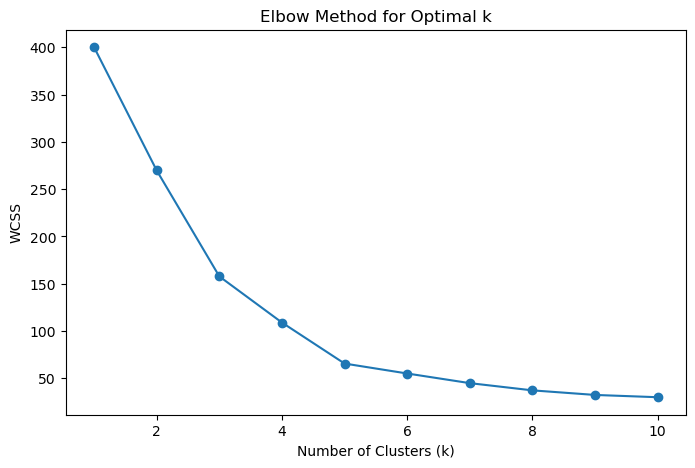

In [5]:
##########DATA CLUSTERING#############
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Use different numbers of clusters
wcss = []
for k in range(1, 11):
    firstkmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    firstkmeans.fit(scaled_features)
    wcss.append(firstkmeans.inertia_)  

#Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

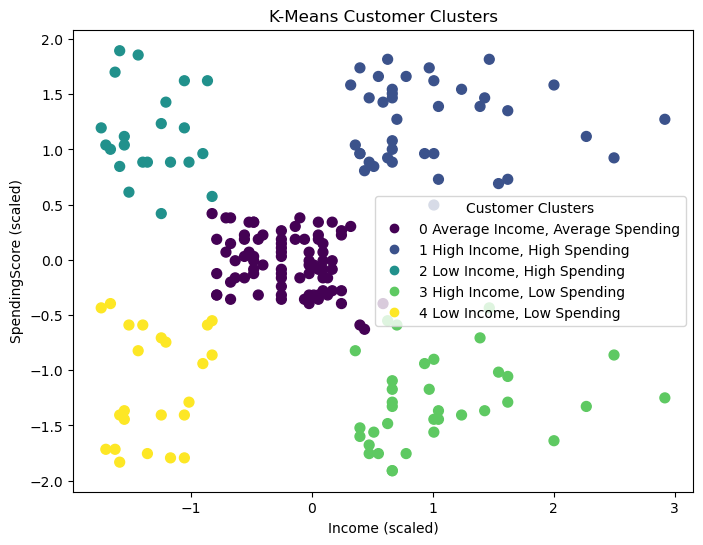

           Age  Gender_Male  Gender_Female
Cluster                                   
0        42.72         0.41           0.59
1        32.69         0.46           0.54
2        25.27         0.41           0.59
3        41.11         0.54           0.46
4        45.22         0.39           0.61


In [6]:
##########Evaluating the Clusters#############
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Final K-Means with with 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_features)

#Plotting the clusters
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    scaled_features[:, 0],
    scaled_features[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

#Plotting Legend
handles, _ = scatter.legend_elements()

cluster_names = [
    "0 Average Income, Average Spending",
    "1 High Income, High Spending",
    "2 Low Income, High Spending",
    "3 High Income, Low Spending",
    "4 Low Income, Low Spending"
]

plt.legend(handles, cluster_names, title="Customer Clusters",
           loc='center right')

plt.xlabel("Income (scaled)")
plt.ylabel("SpendingScore (scaled)")
plt.title("K-Means Customer Clusters")

plt.show()

#Copying data with all features
df = preprocess2.copy()

#Adding cluster column
df['Cluster'] = labels

#Creating dummy variables
df = pd.get_dummies(df, columns=['Gender'])

#Determining the gender distribution and mean age for each cluster
cluster_info = df.groupby('Cluster')[['Age', 'Gender_Male',
                            'Gender_Female']].mean().round(2)
print(cluster_info)